# Практика: работа с выбросами

## Генерируем тестовые данные с аномалиями

Для начала создадим небольшой искусственный набор данных, в котором будут и обычные точки, и выбросы.

In [1]:
import numpy as np
import pandas as pd

# Создаём обычные точки
np.random.seed(627)
x_normal = np.random.normal(0, 1, 1000)
y_normal = np.random.normal(0, 1, 1000)

# Добавляем выбросы
x_outliers = np.random.uniform(6, 8, 50)
y_outliers = np.random.uniform(6, 8, 50)

# Объединяем в один датасет
x = np.concatenate([x_normal, x_outliers])
y = np.concatenate([y_normal, y_outliers])

data = pd.DataFrame({'x': x, 'y': y})

# Отметим, какие точки выбросы (True/False)
data['is_outlier'] = False
data.loc[data.index[-50:], 'is_outlier'] = True

# Проверим количество правильных точек и выбросов
print(data['is_outlier'].value_counts())

is_outlier
False    1000
True       50
Name: count, dtype: int64


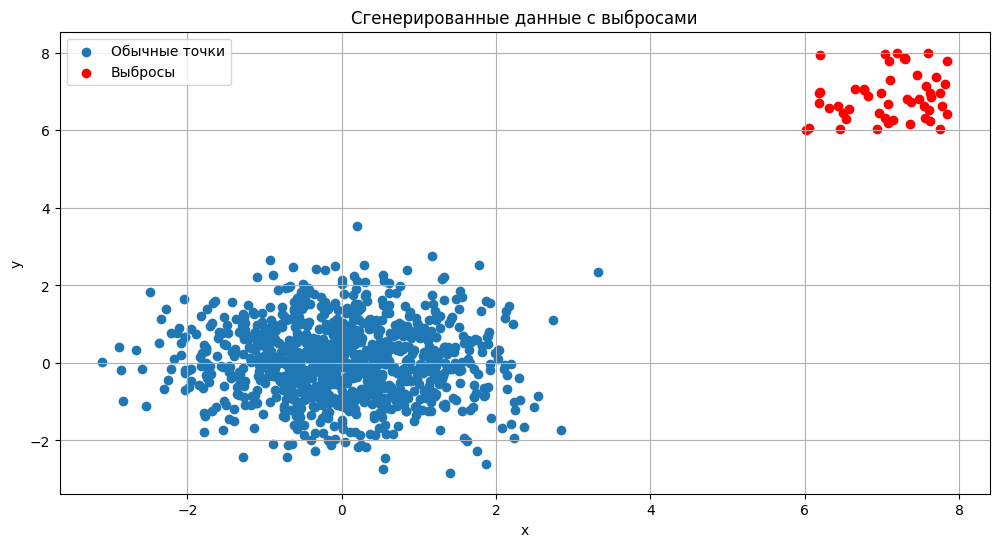

In [2]:
import matplotlib.pyplot as plt

# Покажем данные на графике.
plt.figure(figsize=(12,6))
plt.scatter(data.loc[~data['is_outlier'], 'x'], data.loc[~data['is_outlier'], 'y'], label='Обычные точки')
plt.scatter(data.loc[data['is_outlier'], 'x'], data.loc[data['is_outlier'], 'y'], color='red', label='Выбросы')
plt.legend()
plt.title('Сгенерированные данные с выбросами')
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.show()

## Поиск выбросов

### Метод 1. Фильтрация по пороговому значению


В некоторых случаях есть возможность отделить аномальные значения по порогу. Например, посмотрев на Scatter plot, легко определить, какие точки не принадлежат основному множеству и где проходит граница между ними.

Например, выбросами можно считать все точки, где x > 3 или y > 3.

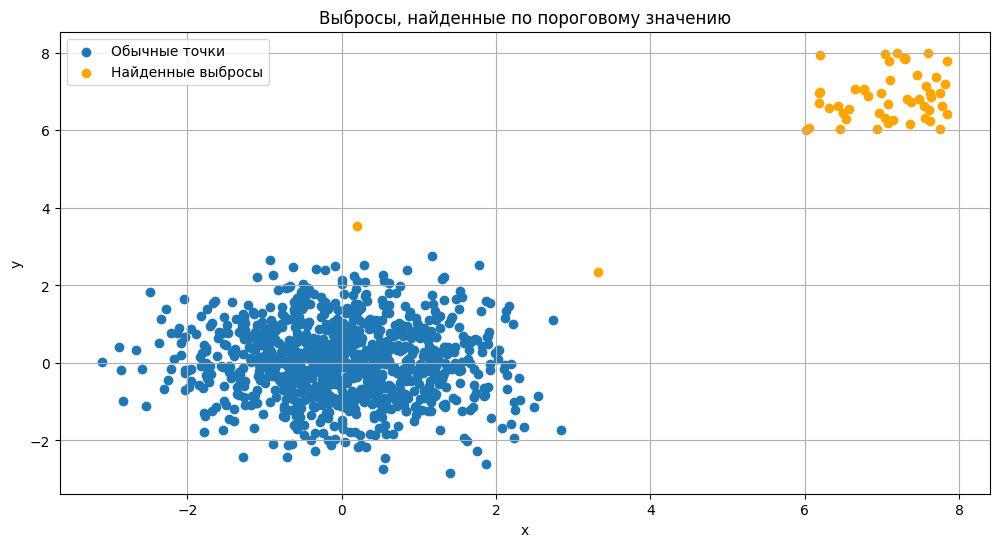

In [3]:
import matplotlib.pyplot as plt

# Зададим условие для фильтрации выбросов
outlier_mask = (data['x'] > 3) | (data['y'] > 3)
data['detected_outlier'] = outlier_mask

# Визуализируем результат
plt.figure(figsize=(12, 6))
plt.scatter(data.loc[~outlier_mask, 'x'], data.loc[~outlier_mask, 'y'], label='Обычные точки')
plt.scatter(data.loc[outlier_mask, 'x'], data.loc[outlier_mask, 'y'], color='orange', label='Найденные выбросы')
plt.legend()
plt.title('Выбросы, найденные по пороговому значению')
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.show()

### Метод 2. Фильтрация по количеству стандартных отклонений


Второй подход полагается на свойства распределения. Вместо явного порога можно использовать Z-оценку: сначала определить, насколько каждая точка отклоняется от среднего значения, и считать выбросами те, что отклоняются больше чем на три стандартных отклонения.

Этот способ учитывает общее поведение признака и хорошо работает, если распределение данных близко к нормальному.

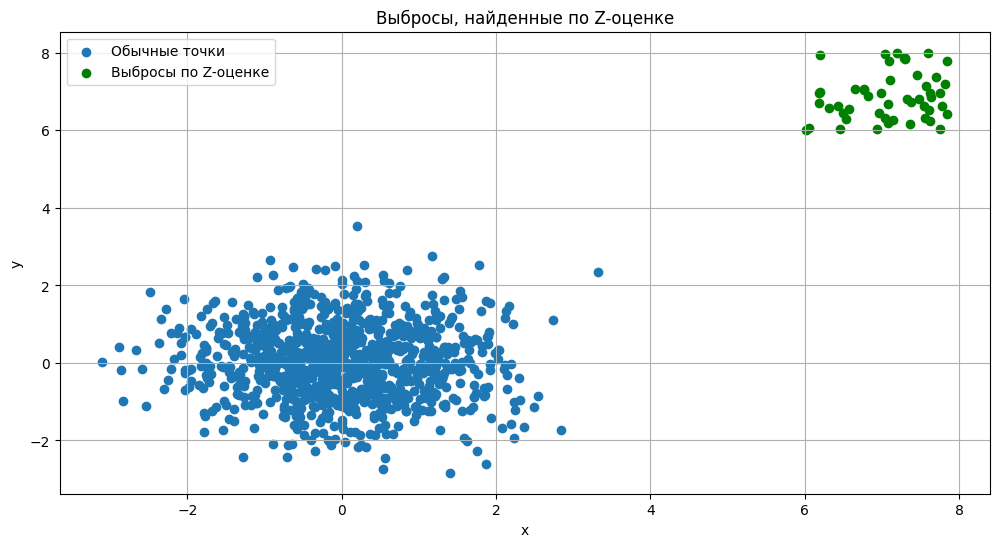

In [4]:
from scipy.stats import zscore
import matplotlib.pyplot as plt

# Посчитаем, на сколько стандартных отклонений (z) удалена каждая точка
data['z_x'] = zscore(data['x'])
data['z_y'] = zscore(data['y'])

# Отфильтруем строки в зависимости от результата
z_outlier_mask = (data['z_x'].abs() > 3) | (data['z_y'].abs() > 3)

plt.figure(figsize=(12, 6))
plt.scatter(data.loc[~z_outlier_mask, 'x'], data.loc[~z_outlier_mask, 'y'], label='Обычные точки')
plt.scatter(data.loc[z_outlier_mask, 'x'], data.loc[z_outlier_mask, 'y'], color='green', label='Выбросы по Z-оценке')
plt.legend()
plt.title('Выбросы, найденные по Z-оценке')
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.show()

## Обработка выбросов

### Удаление выбросов

Задание 1

Оставьте в датасете только те точки, которые прошли проверку z-оценкой. Используйте для этого `z_outlier_mask`.

In [10]:
print('Общее количество точек:', len(data))

# Отфильтруйте выбросы в data и сохраните результат в новый датасет
filtered_data = data.where(~z_outlier_mask).dropna()

print('Количество точек без выбросов:', len(filtered_data))

Общее количество точек: 1050
Количество точек без выбросов: 1000


Проверим данные, после удаления выбросов

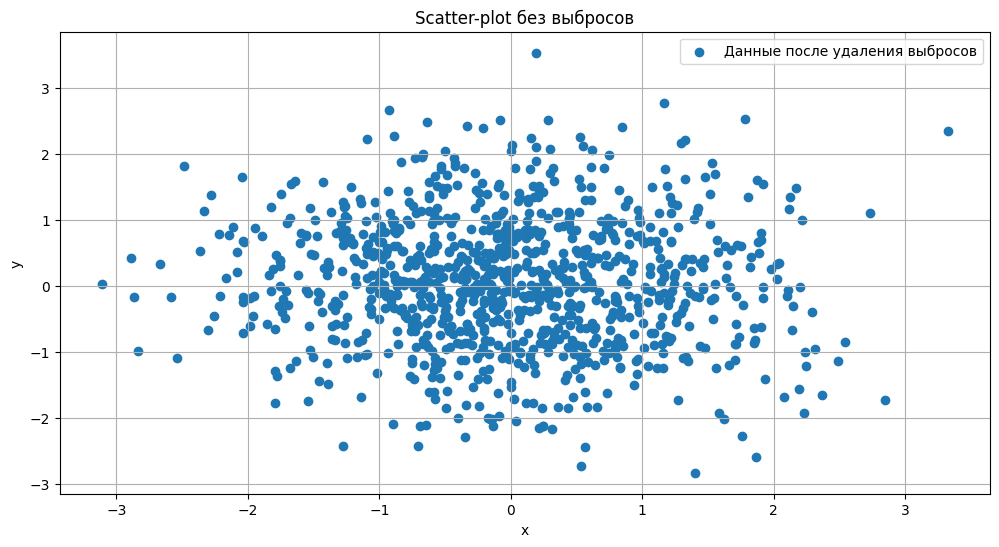

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.scatter(filtered_data['x'], filtered_data['y'], label='Данные после удаления выбросов')
plt.title('Scatter-plot без выбросов')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid()
plt.show()

### Замена выбросов


Вместо удаления можно заменить выбросы на определённые значения, подходящие для признака (нули, медианы).

В нашем случае лучшим выбором будет медиана.

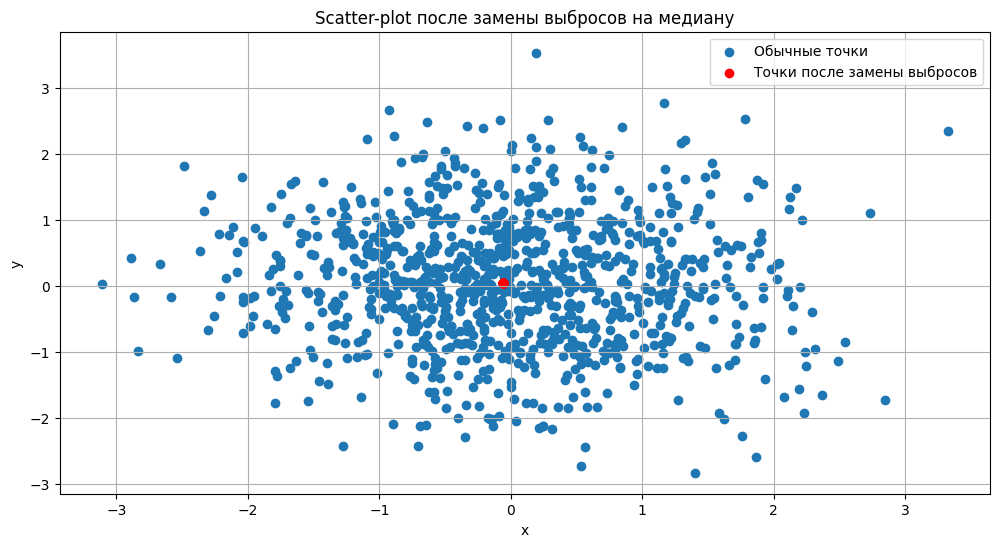

In [12]:
import matplotlib.pyplot as plt

data_replaced = data.copy()
median_x = data_replaced.loc[~z_outlier_mask, 'x'].median()
median_y = data_replaced.loc[~z_outlier_mask, 'y'].median()

data_replaced.loc[z_outlier_mask, 'x'] = median_x
data_replaced.loc[z_outlier_mask, 'y'] = median_y

# Убедимся, что все выбросы «переместились» в центр облака данных
plt.figure(figsize=(12, 6))
plt.scatter(data_replaced.loc[~data['is_outlier'], 'x'], data_replaced.loc[~data['is_outlier'], 'y'], label='Обычные точки')
plt.scatter(data_replaced.loc[data['is_outlier'], 'x'], data_replaced.loc[data['is_outlier'], 'y'], color='red', label='Точки после замены выбросов')
plt.title('Scatter-plot после замены выбросов на медиану')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid()
plt.show()

Все точки, которые были выбросами, теперь занимают одну и ту же позицию (отмеченную красным). Такой способ может быть полезен, если не хочется терять строки (например, потому что их мало), но важно избавиться от экстремальных значений.